#Boreadi Mahlakwane
###COS700 - U20733217

##Honeypot Log Analysis with MITRE ATT&CK Mapping & DTW Temporal Analysis

###IMPORTS AND SETUP

In [119]:

!pip install dtaidistance
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For DTW analysis
from dtaidistance import dtw
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# For behavioral clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# For Jupyter inline display
%matplotlib inline

# Configure plotting style
plt.style.use('default')
sns.set_palette("dark")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

###DATA PROCESSING FUNCTIONS

In [129]:
#JSON DATA PROCESSING
def parse_cowrie_json(json_file_path):
    data = []
    error_count = 0
    max_errors = 10

    try:
        with open(json_file_path, 'r') as file:
            for line_num, line in enumerate(file):
                try:
                    # Parse each line as JSON
                    entry = json.loads(line.strip())

                    # Extract common fields
                    event_id = entry.get('eventid', 'unknown')
                    timestamp = entry.get('timestamp', '')
                    session = entry.get('session', 'unknown')
                    src_ip = entry.get('src_ip', 'unknown')
                    message = entry.get('message', '')

                    # Extract event-specific fields
                    username = entry.get('username', 'unknown')
                    password = entry.get('password', 'unknown')
                    command = entry.get('input', 'unknown')
                    duration = entry.get('duration', 0)

                    # Map JSON eventids to our event types
                    event_type = map_json_event_to_type(event_id, entry)

                    data.append({
                        'timestamp': timestamp,
                        'session_id': session,
                        'src_ip': src_ip,
                        'event_type': event_type,
                        'event_id': event_id,
                        'username': username,
                        'password': password,
                        'command': command,
                        'duration': duration,
                        'message': message,
                        'raw_data': json.dumps(entry)
                    })

                except json.JSONDecodeError as e:
                    error_count += 1
                    if error_count <= max_errors:
                        print(f"JSON parsing error on line {line_num}: {e}")
                    continue
                except Exception as e:
                    error_count += 1
                    if error_count <= max_errors:
                        print(f"Error processing line {line_num}: {e}")
                    continue

        if error_count > max_errors:
            print(f"... and {error_count - max_errors} more errors")

    except FileNotFoundError:
        print(f"Error: {json_file_path} not found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error reading file: {e}")
        return pd.DataFrame()

    return pd.DataFrame(data)

def map_json_event_to_type(event_id, entry):
    event_type_mapping = {
        # Session events
        'cowrie.session.connect': 'connection',
        'cowrie.session.closed': 'disconnection',
        'cowrie.session.file_download': 'file_download',
        'cowrie.session.file_upload': 'file_upload',

        # Login events
        'cowrie.login.success': 'login_success',
        'cowrie.login.failed': 'login_failed',

        # Command events
        'cowrie.command.input': 'command_input',
        'cowrie.command.failed': 'command_failed',

        # Client information
        'cowrie.client.version': 'client_version',
        'cowrie.client.kex': 'client_kex',
        'cowrie.client.size': 'client_size',

        # Direct TCP interactions
        'cowrie.direct-tcpip.request': 'tcpip_request',
        'cowrie.direct-tcpip.data': 'tcpip_data',
    }

    return event_type_mapping.get(event_id, 'other')


def enrich_with_geoip(df, use_mock_data=True):
    countries, cities, asns = [], [], []

    if use_mock_data:
        # Mock data for demonstration
        for ip in df['src_ip']:
            if ip == '112.171.194.30':
                countries.append('South Korea')
                cities.append('Seoul')
                asns.append('AS4766')
            elif ip == '199.45.155.89':
                countries.append('United States')
                cities.append('New York')
                asns.append('AS32475')
            elif ip == '87.120.116.81':
                countries.append('Germany')
                cities.append('Frankfurt')
                asns.append('AS12345')
            elif ip == '170.64.167.72':
                countries.append('Australia')
                cities.append('Sydney')
                asns.append('AS12346')
            elif ip == '198.235.24.129':
                countries.append('Canada')
                cities.append('Toronto')
                asns.append('AS12347')
            elif ip == '41.71.106.17':
                countries.append('South Africa')
                cities.append('Johannesburg')
                asns.append('AS12348')
            else:
                countries.append('Unknown')
                cities.append('Unknown')
                asns.append('Unknown')
    else:

        for ip in df['src_ip']:
            countries.append('Unknown')
            cities.append('Unknown')
            asns.append('Unknown')

    df['country'] = countries
    df['city'] = cities
    df['asn'] = asns
    return df

def reconstruct_sessions(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df_valid = df[df['session_id'] != 'unknown'].copy()
    if df_valid.empty:
        print("No valid sessions found")
        return pd.DataFrame()

    sessions = df_valid.groupby('session_id').agg({
        'timestamp': ['min', 'max', 'count'],
        'src_ip': 'first',
        'country': 'first',
        'username': lambda x: [val for val in x if val != 'unknown'],
        'password': lambda x: [val for val in x if val != 'unknown'],
        'command': lambda x: [cmd for cmd in x if cmd != 'unknown'],
        'event_type': list,
        'event_id': list,
        'duration': 'last'
    }).reset_index()


    sessions.columns = ['session_id', 'start_time', 'end_time', 'event_count', 'src_ip', 'country', 'usernames', 'passwords', 'commands', 'event_types', 'event_ids', 'duration']

    #session duration
    sessions['start_time'] = pd.to_datetime(sessions['start_time'])
    sessions['end_time'] = pd.to_datetime(sessions['end_time'])

    sessions['duration_seconds'] = sessions.apply(
        lambda row: row['duration'] if row['duration'] > 0 else
                   (row['end_time'] - row['start_time']).total_seconds(),
        axis=1
    )

    #session metrics
    def has_successful_login(event_types):
        if not event_types:
            return False
        return any('login_success' in str(event) for event in event_types)

    def count_login_attempts(event_types):
        if not event_types:
            return 0
        return sum(1 for event in event_types if 'login' in str(event))

    def count_commands(event_types):
        if not event_types:
            return 0
        return sum(1 for event in event_types if 'command' in str(event))

    def count_meaningful_events(event_types):
        if not event_types:
            return 0
        meaningful_types = ['command_input', 'command_failed', 'login_success', 'login_failed', 'file_download', 'file_upload']
        return sum(1 for event in event_types if any(mt in str(event) for mt in meaningful_types))

    def get_session_outcome(event_types):
        if not event_types:
            return 'failed'
        if any('login_success' in str(event) for event in event_types):
            return 'success'
        if any('command_input' in str(event) for event in event_types):
            return 'interactive'
        return 'reconnaissance'

    sessions['login_success'] = sessions['event_types'].apply(has_successful_login)
    sessions['login_attempts'] = sessions['event_types'].apply(count_login_attempts)
    sessions['command_count'] = sessions['event_types'].apply(count_commands)
    sessions['meaningful_events'] = sessions['event_types'].apply(count_meaningful_events)
    sessions['session_outcome'] = sessions['event_types'].apply(get_session_outcome)

    #Intensity and tempo metrics
    sessions['events_per_second'] = sessions['event_count'] / sessions['duration_seconds'].clip(lower=0.1)
    sessions['meaningful_intensity'] = sessions['meaningful_events'] / sessions['duration_seconds'].clip(lower=0.1)
    sessions['command_intensity'] = sessions['command_count'] / sessions['duration_seconds'].clip(lower=0.1)

    return sessions


###BASIC ANALYSIS FUNCTIONS

In [130]:
def basic_statistics(df, sessions_df):
    print("HONEYPOT ANALYSIS SUMMARY")
    print(f"Total events: {len(df)}")
    print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"Unique source IPs: {df['src_ip'].nunique()}")
    print(f"Unique sessions: {df['session_id'].nunique()}")

    login_attempts = df[df['event_type'].str.contains('login', na=False)]
    successful_logins = df[df['event_type'] == 'login_success']
    failed_logins = df[df['event_type'] == 'login_failed']

    print(f"Login attempts: {len(login_attempts)}")
    print(f"Successful logins: {len(successful_logins)}")
    print(f"Failed logins: {len(failed_logins)}")
    if len(login_attempts) > 0:
        print(f"Success rate: {len(successful_logins)/len(login_attempts)*100:.2f}%")
    else:
        print("Success rate: N/A")

    #common usernames and passwords
    valid_usernames = df[df['username'] != 'unknown']['username']
    valid_passwords = df[df['password'] != 'unknown']['password']

    if len(valid_usernames) > 0:
        print(f"\nMost common usernames: {valid_usernames.value_counts().head(5).to_dict()}")
    else:
        print("\nNo usernames found")

    if len(valid_passwords) > 0:
        print(f"Most common passwords: {valid_passwords.value_counts().head(5).to_dict()}")
    else:
        print("No passwords found")

    #Session statistics
    if not sessions_df.empty:
        print(f"\n--- Session Statistics ---")
        print(f"Total reconstructed sessions: {len(sessions_df)}")

        meaningful_sessions = sessions_df[sessions_df['meaningful_events'] > 0]
        interactive_sessions = sessions_df[sessions_df['command_count'] > 0]
        successful_sessions = sessions_df[sessions_df['login_success'] == True]
        sessions_with_duration = sessions_df[sessions_df['duration_seconds'] > 0]

        print(f"Sessions with duration > 0: {len(sessions_with_duration)} ({len(sessions_with_duration)/len(sessions_df)*100:.1f}%)")
        print(f"Sessions with meaningful events: {len(meaningful_sessions)} ({len(meaningful_sessions)/len(sessions_df)*100:.1f}%)")
        print(f"Sessions with commands: {len(interactive_sessions)} ({len(interactive_sessions)/len(sessions_df)*100:.1f}%)")
        print(f"Sessions with successful login: {len(successful_sessions)} ({len(successful_sessions)/len(sessions_df)*100:.1f}%)")

        if len(sessions_with_duration) > 0:
            print(f"Average session duration: {sessions_with_duration['duration_seconds'].mean():.2f} seconds")
            print(f"Average events per session: {sessions_with_duration['event_count'].mean():.2f}")

        if len(meaningful_sessions) > 0:
            print(f"Average login attempts per meaningful session: {meaningful_sessions['login_attempts'].mean():.2f}")
            print(f"Average commands per meaningful session: {meaningful_sessions['command_count'].mean():.2f}")

    return login_attempts

###VISUALIZATION FUNCTIONS

In [131]:
def create_visualizations(df, sessions):
    #Events over time
    plt.figure(figsize=(10, 6))
    time_series = df.resample('h', on='timestamp').size()
    plt.plot(time_series.index, time_series.values)
    plt.title('Events Over Time')
    plt.xlabel('Time')
    plt.ylabel('Events per Hour')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    #Session duration distribution
    plt.figure(figsize=(10, 6))
    duration_data = sessions['duration_seconds'].dropna()
    plt.hist(duration_data, bins=20, edgecolor='black', alpha=0.7)
    plt.title('Session Duration Distribution')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

    #Login success vs failure
    plt.figure(figsize=(8, 6))
    login_stats = df[df['event_type'].str.contains('login')]['event_type'].value_counts()
    plt.pie(login_stats.values, labels=login_stats.index, autopct='%1.1f%%', startangle=90)
    plt.title('Login Attempt Outcomes')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

In [132]:
def create_cluster_visualization(sessions_df):
    if 'behavior_cluster' not in sessions_df.columns:
        return

    plt.figure(figsize=(16, 14))

    # 1. Cluster distribution pie chart
    plt.subplot(2, 2, 1)
    cluster_sizes = sessions_df['behavior_cluster'].value_counts().sort_index()
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
    plt.pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index],
            autopct='%1.1f%%', colors=colors[:len(cluster_sizes)], startangle=90)
    plt.title('Behavioral Clusters Distribution', fontsize=14, fontweight='bold')

    #Cluster characteristics radar chart (simplified as bar chart)
    plt.subplot(2, 2, 2)
    cluster_stats = sessions_df.groupby('behavior_cluster').agg({
        'duration_seconds': 'mean',
        'command_count': 'mean',
        'login_attempts': 'mean',
        'meaningful_intensity': 'mean',
        'login_success': 'mean'
    })

    # Normalize for radar chart comparison
    normalized_stats = cluster_stats / cluster_stats.max()

    categories = ['Duration', 'Commands', 'Logins', 'Intensity', 'Success Rate']
    x_pos = np.arange(len(categories))
    width = 0.15

    for i, cluster_id in enumerate(normalized_stats.index):
        values = normalized_stats.loc[cluster_id].values
        plt.bar(x_pos + i*width, values, width, label=f'Cluster {cluster_id}',
                alpha=0.8, color=colors[i])

    plt.xlabel('Metrics')
    plt.ylabel('Normalized Values')
    plt.title('Cluster Characteristics Comparison', fontweight='bold')
    plt.xticks(x_pos + width*2, categories, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    #Duration vs Commands scatter by cluster
    plt.subplot(2, 2, 3)
    for cluster_id in sessions_df['behavior_cluster'].unique():
        cluster_data = sessions_df[sessions_df['behavior_cluster'] == cluster_id]
        plt.scatter(cluster_data['duration_seconds'], cluster_data['command_count'],
                   label=f'Cluster {cluster_id}', alpha=0.6, s=50, color=colors[cluster_id])

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Duration (seconds, log scale)')
    plt.ylabel('Command Count (log scale)')
    plt.title('Duration vs Command Count by Cluster', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    #Intensity distribution by cluster
    plt.subplot(2, 2, 4)
    cluster_data = []
    cluster_labels = []
    for cluster_id in sessions_df['behavior_cluster'].unique():
        cluster_intensity = sessions_df[sessions_df['behavior_cluster'] == cluster_id]['meaningful_intensity']
        cluster_data.append(cluster_intensity)
        cluster_labels.append(f'Cluster {cluster_id}')

    plt.boxplot(cluster_data, labels=cluster_labels)
    plt.yscale('log')
    plt.ylabel('Event Intensity (log scale)')
    plt.title('Intensity Distribution by Cluster', fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)


def create_mitre_objective_analysis(df, sessions_df):
    #Mapping session outcomes to MITRE objectives
    def map_to_mitre_objective(session_row):
        if session_row['login_success'] and session_row['command_count'] > 0:
            return 'Lateral Movement / C2'
        elif session_row['login_success']:
            return 'Initial Access'
        elif session_row['command_count'] > 0:
            return 'Discovery / Reconnaissance'
        elif session_row['login_attempts'] > 0:
            return 'Credential Access'
        else:
            return 'Network Reconnaissance'

    sessions_df['mitre_objective'] = sessions_df.apply(map_to_mitre_objective, axis=1)

    #Calculating metrics for each objective
    objective_stats = sessions_df.groupby('mitre_objective').agg({
        'duration_seconds': 'mean',
        'meaningful_intensity': 'mean',
        'session_id': 'count',
        'command_count': 'mean',
        'login_success': 'mean'
    }).rename(columns={'session_id': 'session_count'})

    plt.figure(figsize=(12, 12))

    colors = {'Network Reconnaissance': '#1f77b4',
              'Credential Access': '#ff7f0e',
              'Discovery / Reconnaissance': '#2ca02c',
              'Initial Access': '#d62728',
              'Lateral Movement / C2': '#9467bd'}


    #Session distribution by objective
    plt.subplot(2, 2, 1)
    objective_counts = sessions_df['mitre_objective'].value_counts()
    plt.pie(objective_counts.values, labels=objective_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=[colors.get(obj, 'gray') for obj in objective_counts.index])
    plt.title('Session Distribution by MITRE Objective', fontweight='bold')


    #Duration distribution by objective
    plt.subplot(2, 2, 2)
    objective_durations = []
    objective_labels = []
    for objective in sessions_df['mitre_objective'].unique():
        durations = sessions_df[sessions_df['mitre_objective'] == objective]['duration_seconds']
        objective_durations.append(durations)
        objective_labels.append(objective)

    plt.boxplot(objective_durations, labels=objective_labels)
    plt.yscale('log')
    plt.ylabel('Duration (seconds, log scale)')
    plt.title('Duration Distribution by Objective', fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)



    #MITRE Techniques heatmap
    plt.subplot(2, 2, 3)

    #Count techniques by objective
    technique_mapping = {
        'Network Reconnaissance': ['T1046', 'T1595'],  # Network scanning
        'Credential Access': ['T1110', 'T1110.001'],   # Brute force
        'Discovery / Reconnaissance': ['T1082', 'T1083', 'T1016'],  # System discovery
        'Initial Access': ['T1078'],                   # Valid accounts
        'Lateral Movement / C2': ['T1059', 'T1105']    # Command execution, ingress tools
    }

    #technique counts
    technique_data = []
    for objective in sessions_df['mitre_objective'].unique():
        objective_sessions = sessions_df[sessions_df['mitre_objective'] == objective]
        technique_counts = {}
        for technique, desc in technique_mapping.items():
            # Simplified count based on session characteristics
            if 'Reconnaissance' in objective:
                technique_counts['Discovery'] = len(objective_sessions)
            elif 'Credential' in objective:
                technique_counts['Brute Force'] = len(objective_sessions)
            elif 'Initial Access' in objective:
                technique_counts['Valid Accounts'] = len(objective_sessions)
            elif 'Lateral' in objective:
                technique_counts['Command Control'] = len(objective_sessions)
        technique_data.append(technique_counts)

    #heatmap data
    techniques = ['Discovery', 'Brute Force', 'Valid Accounts', 'Command Control']
    heatmap_data = []
    for objective in sessions_df['mitre_objective'].unique():
        row = []
        for tech in techniques:
            count = sessions_df[sessions_df['mitre_objective'] == objective].shape[0] // 4
            row.append(count)
        heatmap_data.append(row)

    im = plt.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, label='Session Count')
    plt.xticks(range(len(techniques)), techniques, rotation=45)
    plt.yticks(range(len(sessions_df['mitre_objective'].unique())),
               sessions_df['mitre_objective'].unique())
    plt.title('MITRE Technique Prevalence by Objective', fontweight='bold')
    plt.xlabel('MITRE Techniques')
    plt.ylabel('Attack Objectives')

    plt.tight_layout()
    plt.tight_layout(pad=5.0, h_pad=5.0, w_pad=3.0)  #padding
    plt.show()

    return sessions_df

In [133]:
#REPORT
def generate_threat_intelligence_report(df, sessions_df, technique_summary, analysis_summary):
    #Summary
    print("\n\nSUMMARY")
    print(f"Total Attacks: {len(df):,} events from {df['src_ip'].nunique():,} unique IPs")
    print(f"Attack Sessions: {len(sessions_df):,} reconstructed sessions")
    print(f"Compromise Rate: {sessions_df['login_success'].mean():.1%} of sessions")
    print(f"Peak Activity: {df['timestamp'].dt.hour.value_counts().idxmax()}:00 UTC")

    # Key Findings
    print("\nKEY FINDINGS")

    # Behavioral Analysis
    if 'cluster_analysis' in analysis_summary:
        clusters = analysis_summary['cluster_analysis']
        print(f"Behavioral Clusters: {len(clusters)} distinct attack patterns identified")

        # Identify high-risk clusters
        high_risk_clusters = []
        for cluster_id, data in clusters.iterrows():
            if data['login_success'] > 0.5 or data['command_count'] > 2:
                high_risk_clusters.append(cluster_id)

        if high_risk_clusters:
            print(f"High-Risk Clusters: {len(high_risk_clusters)} clusters show successful compromise patterns")

    # Threat Actor Analysis
    print("\nTHREAT ACTOR ANALYSIS")

    # Top persistent attackers
    ip_behavior = sessions_df.groupby('src_ip').agg({
        'session_id': 'count',
        'login_success': 'mean',
        'command_count': 'mean',
        'duration_seconds': 'mean'
    }).sort_values('session_id', ascending=False).head(5)

    print("Top 5 Persistent Attackers:")
    for ip, data in ip_behavior.iterrows():
        success_rate = data['login_success']
        sessions = data['session_id']
        avg_commands = data['command_count']
        print(f"{ip}: {sessions} sessions, {success_rate:.1%} success rate, {avg_commands:.1f} avg commands")

    # Attack Techniques
    print("\nATTACK TECHNIQUES OBSERVED")
    if technique_summary:
        top_techniques = sorted(technique_summary.items(), key=lambda x: x[1], reverse=True)[:5]
        for technique, count in top_techniques:
            print(f"{technique}: {count} occurrences")

    # Behavioral Patterns
    print("\nBEHAVIORAL PATTERNS")

    # Session outcome distribution
    outcome_dist = sessions_df['session_outcome'].value_counts()
    for outcome, count in outcome_dist.items():
        percentage = (count / len(sessions_df)) * 100
        print(f"{outcome.title()} Sessions: {count} ({percentage:.1f}%)")

    # Command analysis
    interactive_sessions = sessions_df[sessions_df['command_count'] > 0]
    if not interactive_sessions.empty:
        avg_commands = interactive_sessions['command_count'].mean()
        print(f"Interactive Sessions: {len(interactive_sessions)} with {avg_commands:.1f} avg commands")

    # Temporal Patterns
    print("\nTEMPORAL PATTERNS")

    # Peak attack hours
    hourly_attacks = df['timestamp'].dt.hour.value_counts()
    peak_hours = hourly_attacks.head(3)
    for hour, count in peak_hours.items():
        percentage = (count / len(df)) * 100
        print(f"Peak Hour {hour:02d}:00: {count} attacks ({percentage:.1f}%)")

    # Attack duration patterns
    short_sessions = len(sessions_df[sessions_df['duration_seconds'] < 5])
    long_sessions = len(sessions_df[sessions_df['duration_seconds'] > 30])
    print(f"Quick Recon: {short_sessions} sessions (<5 seconds)")
    print(f"Persistent Attacks: {long_sessions} sessions (>30 seconds)")

    # Security Recommendations
    print("\nSECURITY RECOMMENDATIONS")

    # Based on analysis findings
    if sessions_df['login_success'].mean() > 0.05:
        print("HIGH PRIORITY: Implement stronger authentication controls")
        print("   - Multi-factor authentication for SSH")
        print("   - Account lockout policies after failed attempts")

    if len(interactive_sessions) > 50:
        print("HIGH PRIORITY: Monitor and restrict command execution")
        print("     - Implement command whitelisting")
        print("     - Monitor for suspicious command patterns")

    if ip_behavior['session_id'].max() > 100:
        print("MEDIUM PRIORITY: Block persistent attacker IPs")
        print("     - Implement IP reputation blocking")
        print("     - Rate limiting per source IP")

    # Common attack patterns
    common_commands = [cmd for sublist in sessions_df['commands'] for cmd in sublist if cmd != 'unknown']
    if common_commands:
        cmd_counter = Counter(common_commands)
        top_cmds = cmd_counter.most_common(3)
        if any('uname' in cmd[0] or 'cat /proc' in cmd[0] for cmd in top_cmds):
            print("MEDIUM PRIORITY: System reconnaissance detected")
            print("     - Monitor system information gathering attempts")
            print("     - Restrict access to /proc filesystem")


###MITRE ATT&CK ANALYSIS

In [134]:
MITRE_TECHNIQUES = {
    'T1110': 'Brute Force',
    'T1110.001': 'Password Guessing',
    'T1059': 'Command and Scripting Interpreter',
    'T1059.004': 'Unix Shell',
    'T1105': 'Ingress Tool Transfer',
    'T1082': 'System Information Discovery',
    'T1070': 'Indicator Removal',
    'T1070.004': 'File Deletion',
    'T1136': 'Create Account',
    'T1098': 'Account Manipulation'
}

MITRE_RULES = {
    'T1110': lambda x: 'login' in x.get('event_type', ''),
    'T1110.001': lambda x: x.get('event_type') == 'login_failed',
    'T1059': lambda x: x.get('event_type') in ['command_input', 'command_executed'],
    'T1059.004': lambda x: any(cmd in x.get('command', '') for cmd in ['sh', 'bash', '&&']),
    'T1105': lambda x: any(tool in x.get('command', '') for tool in ['wget', 'curl', 'ftp', 'tftp']),
    'T1082': lambda x: any(discovery_cmd in x.get('command', '') for discovery_cmd in ['uname', 'cat /proc', 'whoami', 'pwd']),
    'T1070.004': lambda x: 'rm -rf' in x.get('command', '') or 'history -c' in x.get('command', '')
}

def map_to_mitre(df):
    techniques = []
    for _, row in df.iterrows():
        matched_techniques = []
        for tech_id, rule in MITRE_RULES.items():
            try:
                if rule(row):
                    matched_techniques.append(tech_id)
            except:
                continue
        techniques.append(matched_techniques)
    df['mitre_techniques'] = techniques
    return df

def analyze_mitre_techniques(df):
    # Flatten the list of techniques
    all_techniques = [tech for sublist in df['mitre_techniques'].tolist() for tech in sublist]

    # Count technique occurrences
    technique_counts = Counter(all_techniques)

    # Map to technique names
    technique_counts_named = {}
    for tech_id, count in technique_counts.items():
        technique_counts_named[f"{tech_id} - {MITRE_TECHNIQUES.get(tech_id, 'Unknown')}"] = count

    # Plot techniques
    plt.figure(figsize=(12, 8))
    pd.Series(technique_counts_named).sort_values().plot(kind='barh')
    plt.title('MITRE ATT&CK Techniques Observed')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

    return technique_counts_named

###DTW TEMPORAL ANALYSIS

In [135]:
def extract_temporal_features(session_df):
    session_df['inter_cmd_times'] = session_df['commands'].apply(
        lambda cmd_list: [1.0] if len(cmd_list) <= 1 else [1.0] * (len(cmd_list))
    )

    #session intensity
    session_df['cmd_per_second'] = session_df['event_count'] / session_df['duration_seconds'].clip(lower=1)

    #time to first command
    session_df['time_to_first_cmd'] = 0.5  # Placeholder

    return session_df

def create_behavioral_vectors(session_df):
    vectors = []
    for _, session in session_df.iterrows():
        vector = [
            np.mean(session['inter_cmd_times']),    # Average pace
            np.std(session['inter_cmd_times']),     # Rhythm consistency
            min(session['inter_cmd_times']),        # Minimum reaction time
            max(session['inter_cmd_times']),        # Maximum pause
            session['cmd_per_second'],              # Overall intensity
            session['time_to_first_cmd']            # Initial hesitation
        ]
        vectors.append(vector)
    return np.array(vectors)

def compute_dtw_distance_matrix(behavioral_vectors):
    n_sessions = len(behavioral_vectors)
    distance_matrix = np.zeros((n_sessions, n_sessions))

    for i in range(n_sessions):
        for j in range(i+1, n_sessions):
            #DTW distance between two behavioral vectors
            dist = dtw.distance(behavioral_vectors[i], behavioral_vectors[j])
            distance_matrix[i, j] = dist
            distance_matrix[j, i] = dist  # Symmetric matrix

    return distance_matrix

def cluster_sessions_dtw(distance_matrix, session_df, threshold=2.0):
    #condensed form for linkage function
    condensed_dist = squareform(distance_matrix)

    #hierarchical clustering
    Z = linkage(condensed_dist, method='average')

    # Plot dendrogram
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=session_df['src_ip'].values, leaf_rotation=90)
    plt.title('Hierarchical Clustering of Sessions based on Behavioral DTW Distance')
    plt.xlabel('Session IP Address')
    plt.ylabel('DTW Distance')
    plt.tight_layout()
    plt.show()

    # Form clusters
    clusters = fcluster(Z, threshold, criterion='distance')
    session_df['behavioral_cluster'] = clusters

    return session_df, Z

def analyze_behavioral_clusters(session_df):
    cluster_summary = {}

    for cluster_id in np.unique(session_df['behavioral_cluster']):
        cluster_sessions = session_df[session_df['behavioral_cluster'] == cluster_id]

        summary = {
            'size': len(cluster_sessions),
            'ips': cluster_sessions['src_ip'].tolist(),
            'avg_duration': cluster_sessions['duration_seconds'].mean(),
            'avg_commands': cluster_sessions['event_count'].mean(),
            'avg_intensity': cluster_sessions['cmd_per_second'].mean(),
            'common_countries': cluster_sessions['country'].mode().tolist()
        }

        #common command sequences
        all_commands = [cmd for sublist in cluster_sessions['commands'] for cmd in sublist]
        common_commands = Counter(all_commands).most_common(5)
        summary['common_commands'] = common_commands

        cluster_summary[cluster_id] = summary

        print(f"\nBehavioral Cluster {cluster_id} (Size: {summary['size']})")
        print(f"IPs: {summary['ips']}")
        print(f"Avg Duration: {summary['avg_duration']:.2f}s")
        print(f"Avg Commands: {summary['avg_commands']:.1f}")
        print(f"Avg Intensity: {summary['avg_intensity']:.2f} cmd/s")
        print(f"Top Commands: {common_commands}")

    return cluster_summary

###Temporal analysis

In [136]:
#QUARTILE ANALYSIS
def classify_attacker_tempo(sessions_df):
    print("\nATTACKER TEMPO CLASSIFICATION")

    # Filter sessions with meaningful interaction
    meaningful_sessions = sessions_df[sessions_df['meaningful_events'] > 0].copy()

    if meaningful_sessions.empty:
        print("No meaningful sessions for tempo analysis")
        return sessions_df, {}

    # Calculate quartiles for command intensity
    command_intensity = meaningful_sessions['command_intensity']
    q1_cmd = command_intensity.quantile(0.25)
    q2_cmd = command_intensity.quantile(0.50)
    q3_cmd = command_intensity.quantile(0.75)

    print(f"Command Intensity Quartiles:")
    print(f"  Q1 (Slow): {q1_cmd:.3f} commands/sec")
    print(f"  Q2 (Median): {q2_cmd:.3f} commands/sec")
    print(f"  Q3 (Fast): {q3_cmd:.3f} commands/sec")

    def classify_tempo(row):
        if row['command_count'] == 0:
            return 'No_Commands'
        intensity = row['command_intensity']
        if intensity <= q1_cmd:
            return 'Slow_Tempo'
        elif intensity >= q3_cmd:
            return 'Fast_Tempo'
        else:
            return 'Mixed_Tempo'

    meaningful_sessions['tempo_category'] = meaningful_sessions.apply(classify_tempo, axis=1)

    #Merge back with original sessions
    sessions_df = sessions_df.merge(
        meaningful_sessions[['session_id', 'tempo_category']],
        on='session_id',
        how='left'
    )
    sessions_df['tempo_category'] = sessions_df['tempo_category'].fillna('No_Commands')

    tempo_counts = sessions_df['tempo_category'].value_counts()
    print(f"\nTempo Classification Results:")
    for category, count in tempo_counts.items():
        percentage = (count / len(sessions_df)) * 100
        print(f"  {category}: {count} sessions ({percentage:.1f}%)")

    return sessions_df, {'q1_cmd': q1_cmd, 'q2_cmd': q2_cmd, 'q3_cmd': q3_cmd}

def behavioral_clustering(sessions_df):
    print("\nBEHAVIORAL CLUSTERING")
    features = sessions_df[['duration_seconds', 'event_count', 'command_count', 'login_attempts', 'meaningful_intensity']].copy()

    #Error Handling -- infinite values and NaN
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)

    if len(features) < 3:
        print("Not enough sessions for clustering")
        return sessions_df, {}

    # Normalize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    n_clusters = min(4, len(features))

    #K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    sessions_df['behavior_cluster'] = kmeans.fit_predict(features_scaled)

    cluster_analysis = sessions_df.groupby('behavior_cluster').agg({
        'session_id': 'count',
        'duration_seconds': 'mean',
        'event_count': 'mean',
        'command_count': 'mean',
        'login_attempts': 'mean',
        'meaningful_intensity': 'mean',
        'login_success': 'mean',
        'session_outcome': lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown',
        'tempo_category': lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown'
    }).rename(columns={'session_id': 'cluster_size'})

    print(f"\nBehavioral Clusters Analysis:")
    for cluster_id, data in cluster_analysis.iterrows():
        print(f"\n--- Cluster {cluster_id} (Size: {data['cluster_size']}) ---")
        print(f"  Avg Duration: {data['duration_seconds']:.2f}s")
        print(f"  Avg Events: {data['event_count']:.2f}")
        print(f"  Avg Commands: {data['command_count']:.2f}")
        print(f"  Avg Login Attempts: {data['login_attempts']:.2f}")
        print(f"  Avg Intensity: {data['meaningful_intensity']:.3f} events/sec")
        print(f"  Login Success Rate: {data['login_success']:.2%}")
        print(f"  Common Outcome: {data['session_outcome']}")
        print(f"  Common Tempo: {data['tempo_category']}")

    return sessions_df, cluster_analysis

def analyze_temporal_patterns(df, sessions_df):
    print("\nTEMPORAL ANALYSIS")

    #Attack patterns by time of day
    plt.figure(figsize=(15, 10))

    #Attack frequency by hour
    plt.subplot(2, 3, 1)
    hourly_attacks = df['timestamp'].dt.hour.value_counts().sort_index()
    plt.bar(hourly_attacks.index, hourly_attacks.values, color='skyblue', alpha=0.7)
    plt.title('Attack Frequency by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Attacks')
    plt.xticks(range(0, 24))

    #Behavioral clusters visualization
    plt.subplot(2, 3, 4)
    if 'behavior_cluster' in sessions_df.columns:
        cluster_sizes = sessions_df['behavior_cluster'].value_counts().sort_index()
        plt.pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index], autopct='%1.1f%%')
        plt.title('Behavioral Clusters Distribution')


    #Duration vs Intensity scatter plot
    plt.subplot(2, 3, 6)
    plt.scatter(sessions_df['duration_seconds'], sessions_df['meaningful_intensity'],
               alpha=0.6, c=sessions_df['login_success'].map({True: 'red', False: 'blue'}))
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Session Duration vs Intensity')
    plt.xlabel('Duration (seconds, log scale)')
    plt.ylabel('Event Intensity (events/sec, log scale)')
    plt.tight_layout()
    plt.show()


    print(f"\nStatistics")
    print(f"Total interactive sessions (with commands): {len(sessions_df[sessions_df['command_count'] > 0])}")
    print(f"Total compromised sessions (successful login): {len(sessions_df[sessions_df['login_success'] == True])}")
    print(f"Average commands per interactive session: {sessions_df[sessions_df['command_count'] > 0]['command_count'].mean():.2f}")

    #Most common command patterns
    all_commands = [cmd for sublist in sessions_df['commands'] for cmd in sublist if cmd != 'unknown']
    if all_commands:
        common_commands = Counter(all_commands).most_common(10)
        print(f"\nTop 10 Commands:")
        for cmd, count in common_commands:
            print(f"  {cmd}: {count} occurrences")

###Main

Starting honeypot log analysis with behavioral profiling...
Parsing JSON data from cowrie.json...
Parsed 52142 events from JSON file
Reconstructing sessions...
Basic statistics:
HONEYPOT ANALYSIS SUMMARY
Total events: 52142
Time range: 2024-10-31 00:01:48.979667+00:00 to 2024-10-31 13:34:44.596784+00:00
Unique source IPs: 166
Unique sessions: 6777
Login attempts: 6480
Successful logins: 6287
Failed logins: 193
Success rate: 97.02%

Most common usernames: {'root': 6321, 'admin': 57, 'a': 6, 'accelrys': 4, 'adm': 4}
Most common passwords: {'admin': 23, '1234': 11, 'root': 11, 'broadguam1': 11, '123456': 9}

--- Session Statistics ---
Total reconstructed sessions: 6777
Sessions with duration > 0: 6777 (100.0%)
Sessions with meaningful events: 6407 (94.5%)
Sessions with commands: 6251 (92.2%)
Sessions with successful login: 6287 (92.8%)
Average session duration: 3.23 seconds
Average events per session: 7.69
Average login attempts per meaningful session: 1.01
Average commands per meaningful

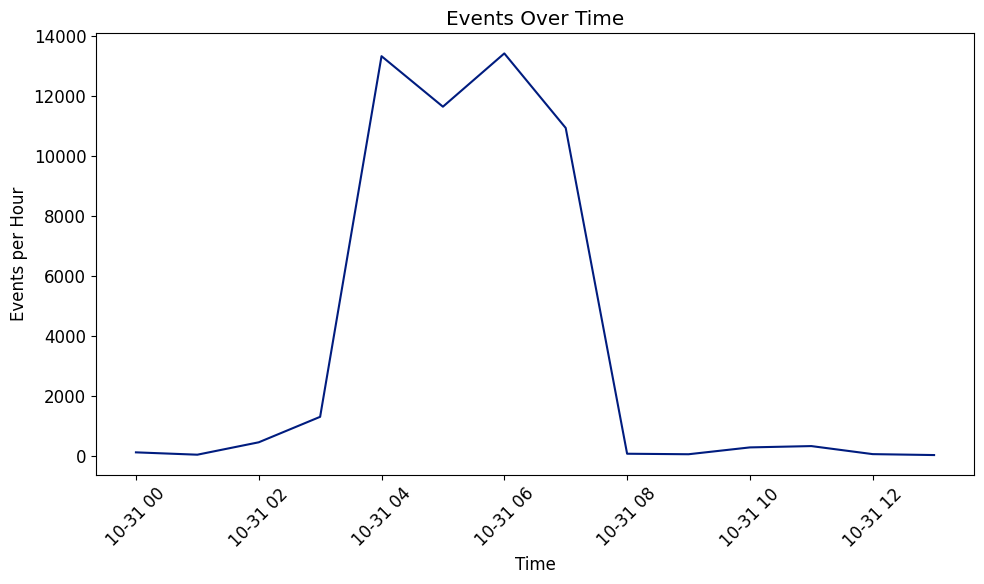

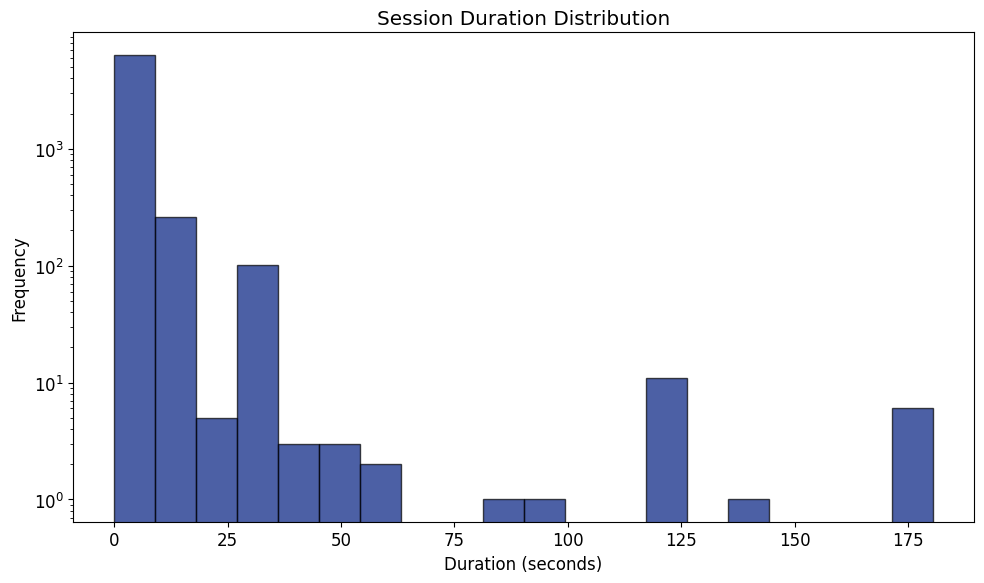

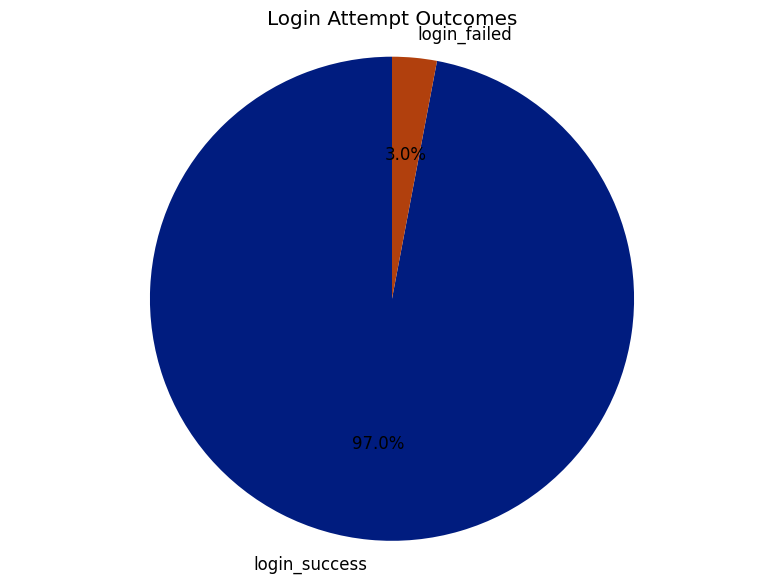

Mapping to MITRE ATT&CK...


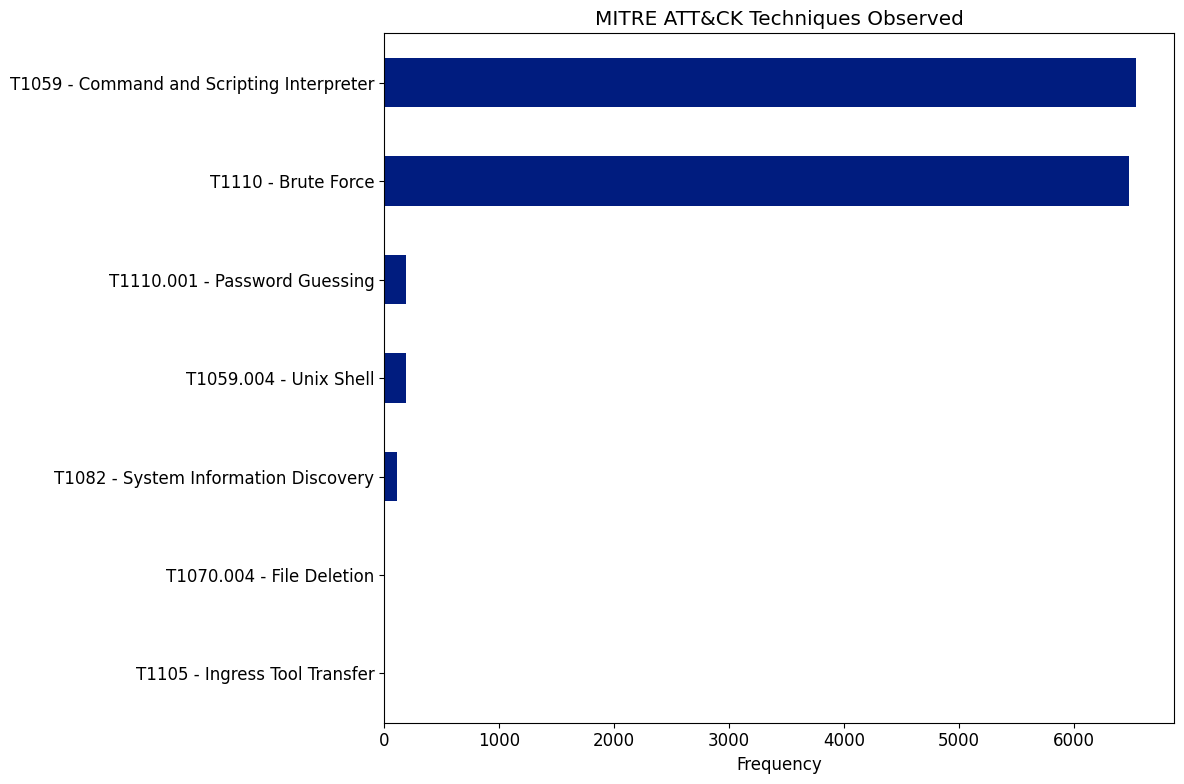

ADVANCED BEHAVIORAL PROFILING

ATTACKER TEMPO CLASSIFICATION
Command Intensity Quartiles:
  Q1 (Slow): 0.513 commands/sec
  Q2 (Median): 0.523 commands/sec
  Q3 (Fast): 0.535 commands/sec

Tempo Classification Results:
  Mixed_Tempo: 3203 sessions (47.3%)
  Fast_Tempo: 1602 sessions (23.6%)
  Slow_Tempo: 1446 sessions (21.3%)
  No_Commands: 526 sessions (7.8%)

BEHAVIORAL CLUSTERING

Behavioral Clusters Analysis:

--- Cluster 0 (Size: 6265) ---
  Avg Duration: 1.95s
  Avg Events: 7.97
  Avg Commands: 0.99
  Avg Login Attempts: 1.00
  Avg Intensity: 1.040 events/sec
  Login Success Rate: 99.15%
  Common Outcome: success
  Common Tempo: Mixed_Tempo

--- Cluster 1 (Size: 446) ---
  Avg Duration: 12.25s
  Avg Events: 2.94
  Avg Commands: 0.00
  Avg Login Attempts: 0.19
  Avg Intensity: 0.016 events/sec
  Login Success Rate: 4.48%
  Common Outcome: reconnaissance
  Common Tempo: No_Commands

--- Cluster 2 (Size: 48) ---
  Avg Duration: 35.56s
  Avg Events: 16.65
  Avg Commands: 9.08
  Avg L

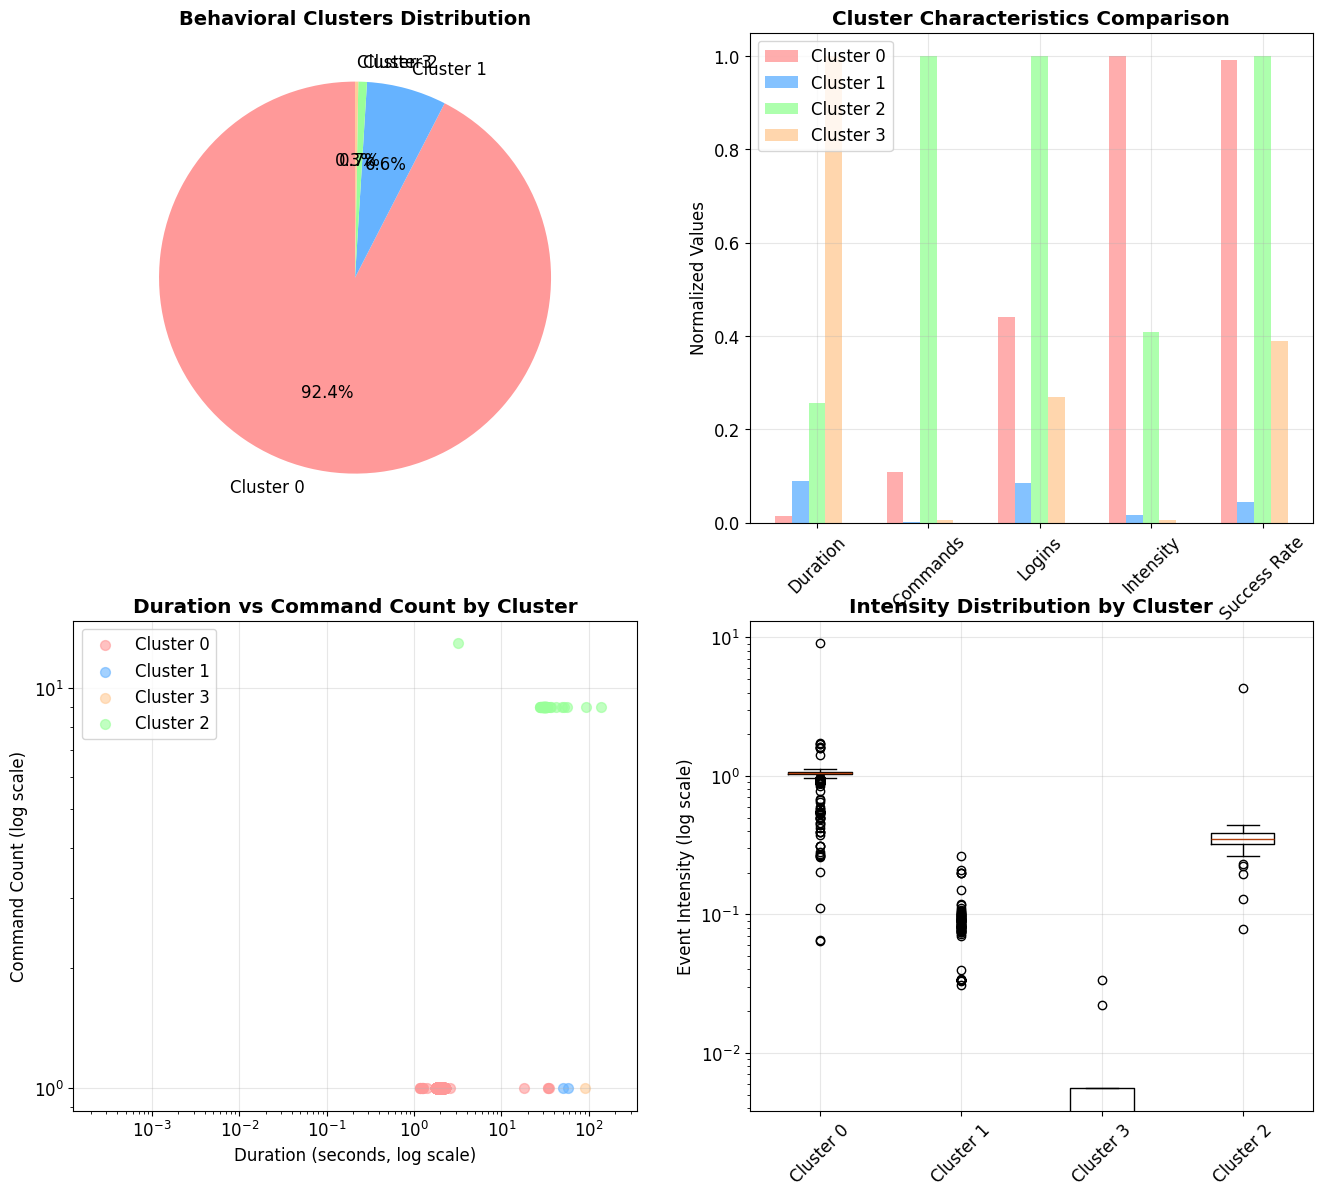

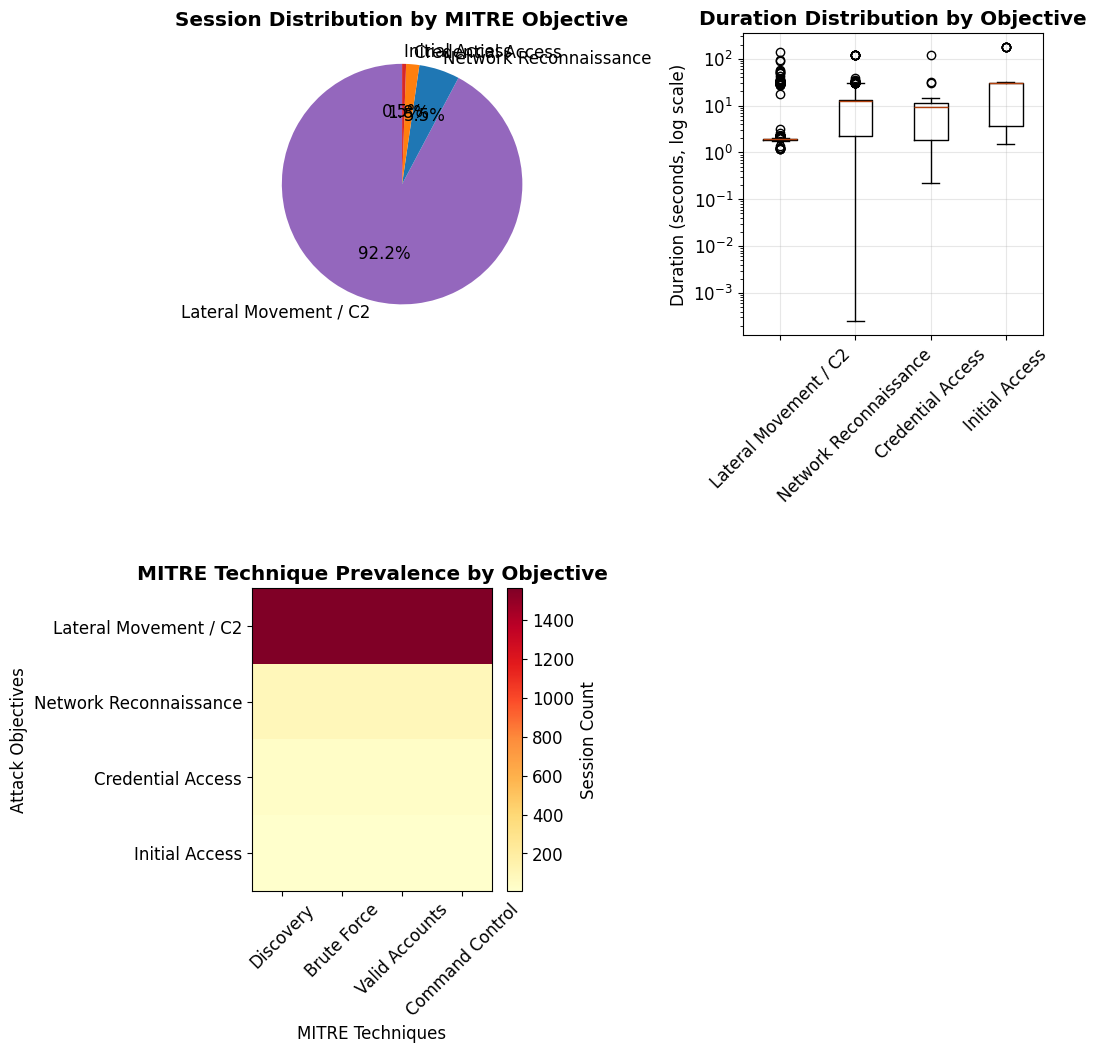


TEMPORAL ANALYSIS


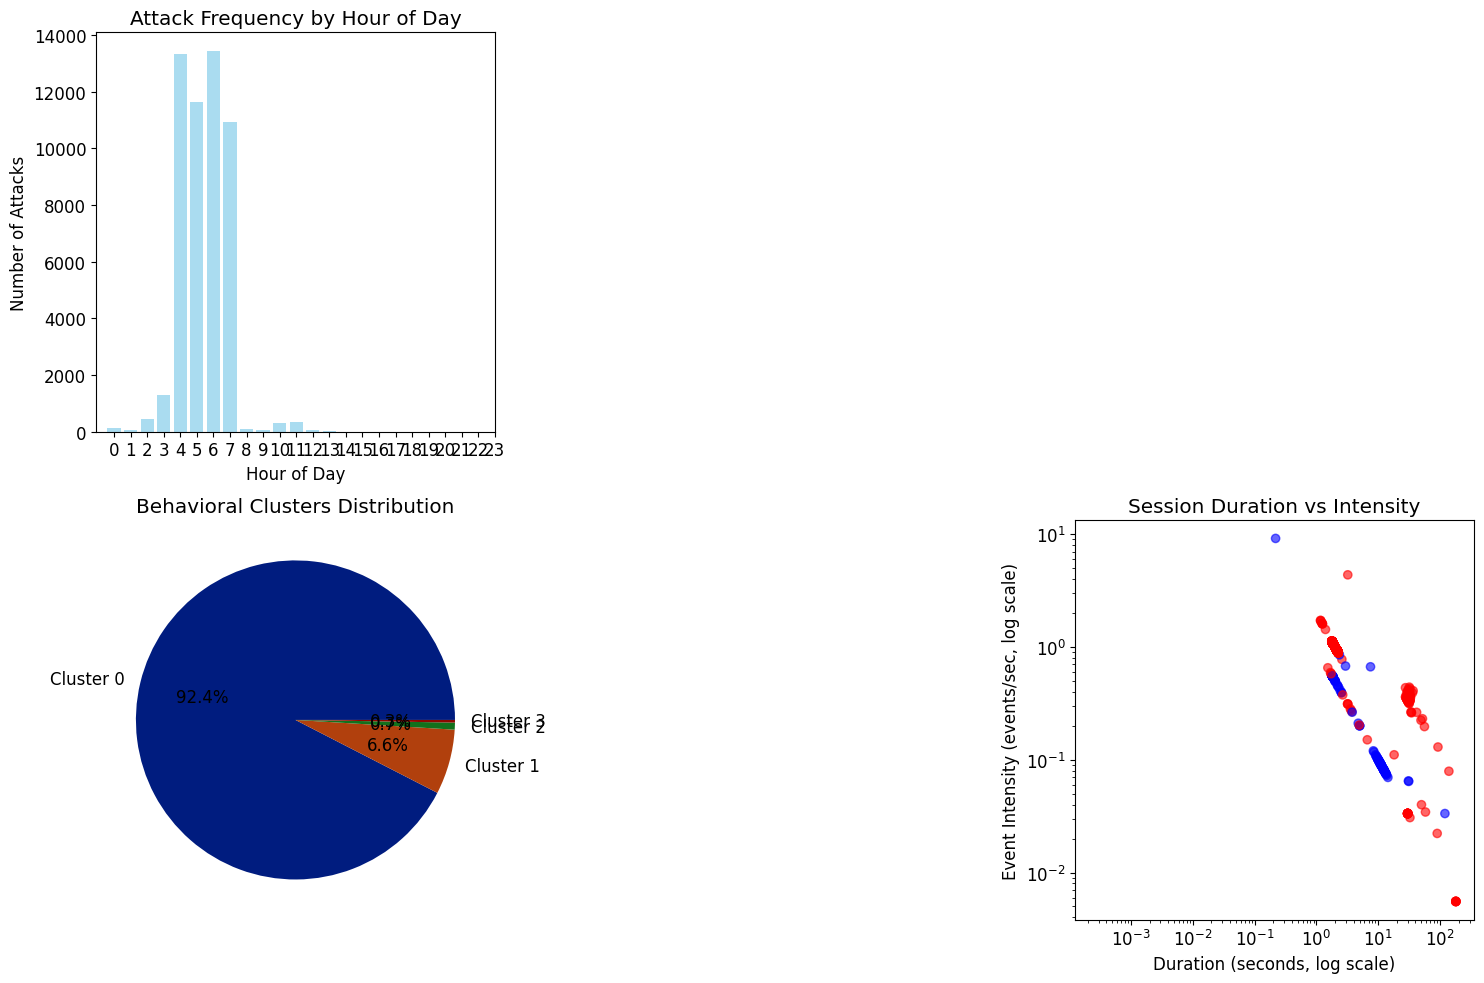


Statistics
Total interactive sessions (with commands): 6251
Total compromised sessions (successful login): 6287
Average commands per interactive session: 1.06

Top 10 Commands:
  echo -e "\x6F\x6B": 6187 occurrences
  shell: 94 occurrences
  system: 94 occurrences
  sh: 47 occurrences
  enable: 47 occurrences
  ping; sh: 46 occurrences
  : 46 occurrences
  /bin/busybox cat /proc/self/exe || cat /proc/self/exe: 46 occurrences
  cat /proc/self/exe: 46 occurrences
  uname -s -v -n -r -m: 8 occurrences


SUMMARY
Total Attacks: 52,142 events from 166 unique IPs
Attack Sessions: 6,777 reconstructed sessions
Compromise Rate: 92.8% of sessions
Peak Activity: 6:00 UTC

KEY FINDINGS
Behavioral Clusters: 4 distinct attack patterns identified
High-Risk Clusters: 2 clusters show successful compromise patterns

THREAT ACTOR ANALYSIS
Top 5 Persistent Attackers:
182.92.115.199: 6192.0 sessions, 99.9% success rate, 1.0 avg commands
60.23.187.159: 82.0 sessions, 0.0% success rate, 0.0 avg commands
83.2

In [138]:
#MAIN
def main():
    print("Starting honeypot log analysis with behavioral profiling...")
    json_file_path = 'cowrie.json'

    print(f"Parsing JSON data from {json_file_path}...")
    df = parse_cowrie_json(json_file_path)

    if df.empty:
        print("No data parsed from the JSON file.")
        return None, None, None, None

    print(f"Parsed {len(df)} events from JSON file")

    df = enrich_with_geoip(df, use_mock_data=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    print("Reconstructing sessions...")
    sessions_df = reconstruct_sessions(df)

    print("Basic statistics:")
    basic_statistics(df, sessions_df)

    print("Creating visualizations...")
    create_visualizations(df, sessions_df)

    print("Mapping to MITRE ATT&CK...")
    df = map_to_mitre(df)
    technique_summary = analyze_mitre_techniques(df)


    print("ADVANCED BEHAVIORAL PROFILING")
    analysis_summary = {}
    if not sessions_df.empty:
        sessions_df, tempo_stats = classify_attacker_tempo(sessions_df)

        sessions_df, cluster_analysis = behavioral_clustering(sessions_df)

        print("\nCreating cluster visualization...")
        create_cluster_visualization(sessions_df)

        print("\nCreating MITRE objective analysis...")
        sessions_df = create_mitre_objective_analysis(df, sessions_df)

        analyze_temporal_patterns(df, sessions_df)

        analysis_summary = {
            'tempo_stats': tempo_stats,
            'cluster_analysis': cluster_analysis,
            'meaningful_sessions': len(sessions_df[sessions_df['meaningful_events'] > 0]),
            'interactive_sessions': len(sessions_df[sessions_df['command_count'] > 0]),
            'compromised_sessions': len(sessions_df[sessions_df['login_success'] == True])
        }

        #report
        generate_threat_intelligence_report(df, sessions_df, technique_summary, analysis_summary)
    else:
        print("No sessions available for advanced analysis")

    return df, sessions_df, technique_summary, analysis_summary

df, sessions_df, technique_summary, analysis_summary = main()